In [ ]:
!pip install torchinfo

In [ ]:
# import necessary libraries
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchinfo import summary

### Part 1: Load and explore data

In [ ]:
transform = transforms.ToTensor()

In [ ]:
cifar_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

100%|██████████| 170M/170M [03:42<00:00, 766kB/s]


In [ ]:
cifar_test = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

In [ ]:
print("Training dataset size:", len(cifar_train))
print("Test dataset size:", len(cifar_test))
print("Image shape:", cifar_train[0][0].shape)
print("Number of classes:", len(cifar_train.classes))
print("Class labels", cifar_train.classes)

Training dataset size: 50000
Test dataset size: 10000
Image shape: torch.Size([3, 32, 32])
Number of classes: 10
Class labels ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


The CIFAR10 dataset consists of 50,000 training imagesand 10,000 test images. Each image has a shape of(3, 32, 32), indicating that the images are 32×32 pixels with 3 color channels(RGB). The dataset contains 10 distinct classes, representing different object categories such as airplane, automobile, bird, cat, deer, dog, frog, horse, ship and truck. This confirms that the task is a multi-class image classification problem, where the model must correctly classify each image into one of these 10 categories.

### Part 2: Preprocess the data

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),
                         (0.5,0.5,0.5))
])

In [ ]:
cifar_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

In [ ]:
cifar_test = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

In [ ]:
train_loader = torch.utils.data.DataLoader(cifar_train, batch_size=64, shuffle=True)

In [ ]:
test_loader = torch.utils.data.DataLoader(cifar_test, batch_size=64, shuffle=False)

In [ ]:
def imageshow(img):
  img = img/2+0.5
  img=img.permute(1,2,0)
  plt.imshow(img)
  plt.axis("off")

In [ ]:
data_iter = iter(train_loader)
image, labels = next(data_iter)

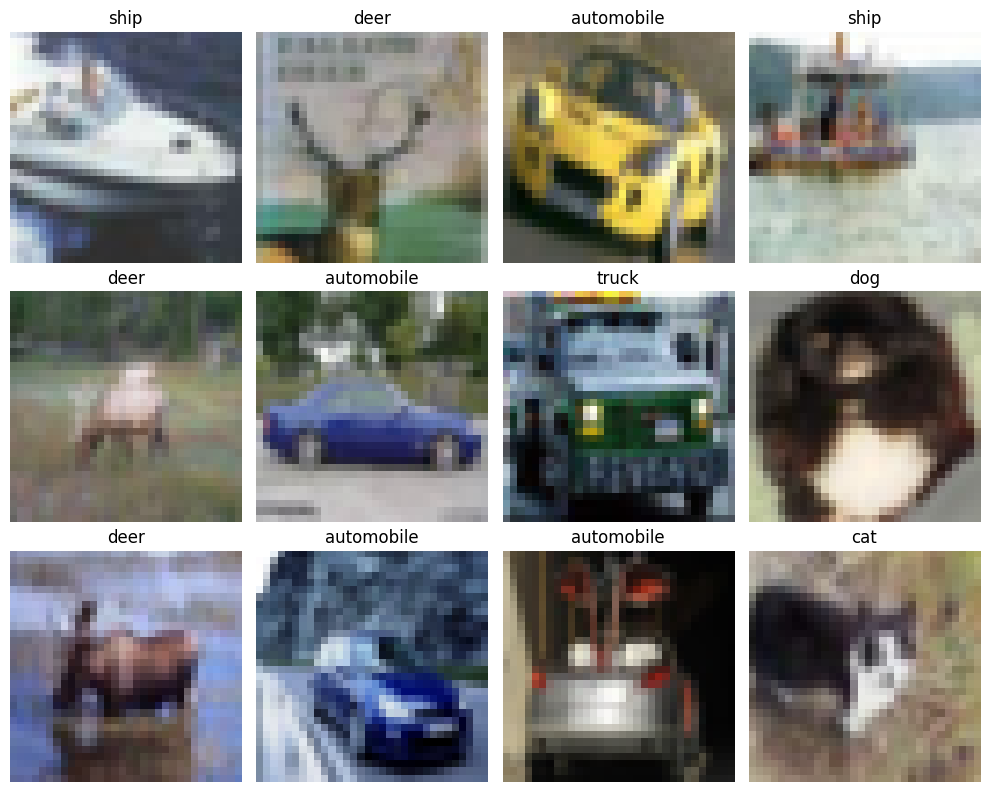

In [ ]:
plt.figure(figsize=(10,8))
for i in range(12):
  plt.subplot(3,4,i+1)
  imageshow(image[i])
  plt.title(cifar_train.classes[labels[i]])

plt.tight_layout()
plt.show()

The images were converted into tensors and normalized to improve training performance. The data was then divided into batches using a DataLoader, which helps with efficient computation and memory management. Training data was shuffled to improve generalization. A 3×4 grid of sample images from the training dataset was displayed to verify that the preprocessing steps were applied correctly. Each image is labelled with its corresponding class, confirming that the dataset is loaded and mapped properly. The images appear low resolution since CIFAR10 consists of 32×32 pixel images and some classes may look visually similar, which makes the classification task more challenging.

### Part 3: Build CNN model

In [ ]:
class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()

    self.conv_layers = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.LeakyReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2)
    )

    self.fc_layers = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128*4*4, 256),
        nn.ReLU(),
        nn.Linear(256,10)
    )

  def forward(self, x):
    x = self.conv_layers(x)
    x = self.fc_layers(x)
    return x


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
cnn_model = CNN().to(device)

In [ ]:
summary(cnn_model, input_size = (3,32,32))

In [ ]:
densenet_model = models.densenet121(weights = None)

num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 10)
model = model.to(device)

print(model)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total Parameters:", total_params)
print("Trainable Parameters:", trainable_params)
print("Final Classifier:", model.classifier)

Total Parameters: 6964106
Trainable Parameters: 6964106
Final Classifier: Linear(in_features=1024, out_features=10, bias=True)


The model used in this project is DenseNet-121, a convolutional neural network architecture that uses dense connections between layers. Unlike a traditional CNN, where each layer only receives input from the previous layer, densenet connects each layer to all preceding layers. This improves featuer reuse and helps gradients flow more effctively during training.\
The architecture begins with an initial convolutional layer followed by batch normalization, relu activation and max pooling. It then consists of multiple dense blocks, where each layer receives inputs from al earlier layers, allowing the network to reuse features instead of releaning them. Between dense blocks, transition layers are used to reduce the number of feature maps and downsample the spatial dimensions using 1×1 convolutions and average pooling. At the end of the network, a final fully connected(linear) layer is used for classification.

In this implementation, the classifier was modified to output 10 classes, corresponding to the CIFAR-10 dataset. The model has a total of 6,964,106 trainable parameters and all parameters are updated during training.

### Part 4: Train model for 5 epochs

In [ ]:
# Train CNN mode
criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.0005)

epochs = 5

for epoch in range(epochs):
  running_loss = 0.0
  cnn_model.train()

  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    cnn_optimizer.zero_grad()

    outputs = cnn_model(images)
    loss = criterion(outputs, labels)

    loss.backward()
    cnn_optimizer.step()

    running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(densenet_model.parameters(), lr=0.0005)

epochs = 5

for epoch in range(epochs):
  running_loss = 0.0
  model.train()

  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    running_loss += loss.item()

  print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/5], Loss: 1.3957
Epoch [2/5], Loss: 0.9973
Epoch [3/5], Loss: 0.8034
Epoch [4/5], Loss: 0.6643
Epoch [5/5], Loss: 0.5517


The model was trained for 5 epochs, and the training loss decreased from 1.3957 to 0.5517. This shows that the model is learning meaningful patterns from the training data and improving its predictions over time. The consistent decrease in loss indicates stable training without major issues such as divergence or instability.

### Part 5: Evaluate model on test set

In [ ]:
correct = 0
total = 0

cnn_model.eval()

with torch.no_grad():
  for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)

    outputs = cnn_model(images)
    _, predicted = torch.max(output, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy for CNN Model: {accuracy:.2f}%")

In [ ]:
correct = 0
total = 0

densenet_model.eval()

with torch.no_grad():
  for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy for DenseNet Model: {accuracy:.2f}%")

Test Accuracy: 71.33%


The trained densenet model achieved a test accuracy of 71.33%, indicating that it correctly classified approximately 71% of the unseen test images. This shows that the model has learned meaningful patterns from the training data and is able to generalize reasonably well to new data, although there is still room for improvement.